In [35]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

import os
import time

from collections.abc import Callable
from dataclasses import asdict
from pathlib import Path
from typing import TYPE_CHECKING, Any

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn

from torch.amp.autocast_mode import autocast
from torch.amp.grad_scaler import GradScaler
from torch.optim import Adam
from tqdm import tqdm

from experiments.plotting import (
    _plot_SRE_distribution,
    plot_training_curves,
    view_correlation,
)
from GNN.parameter_search.helpers import objective_GNN, objective_NN
from GNN.physics_aware_NN import GNN, NN, Regressor
from GNN.training.datasets import build_loaders, build_loaders_NN
from GNN.training.train import build_loss, train_model
from GNN.training.train_config import TrainConfig
from GNN.training.utils import (
    collect_dataset_indices,
    collect_dataset_paths,
    evaluate_loss,
    evaluate_r2,
    to_scalar,
    unpack_supervised_batch,
)
from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)
from src.utils import configure_logger

if TYPE_CHECKING:
    from torch_geometric.loader import DataLoader

from GNN.training.train import build_loss, TrainHistory, _run_train_epoch
from GNN.training.runners import _resolve_model_save_path

In [37]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

In [38]:
default_model_hparams = {
    "gnn_hidden": 64,
    "gnn_heads": 2,
    "global_hidden": 32,
    "reg_hidden": 128,
    "num_layers": 3,
    "dropout_rate": 0.10,
}

default_train_hparams = {
    "weight_decay": 3e-3,
    "grad_clip": 1.0,
    "early_stopping_patience": 15,
    "early_stopping_min_delta": 0.0,
    "num_workers": 0,
}

PARAMS = {
    "random" : {
        "lr" : 0.0009860340204413903,
        "batch_size" : 128,
        "model_hparams": {
            "gnn_hidden" : 64,
            "gnn_heads": 2,
            "global_hidden": 32,
            "reg_hidden": 128,
            "num_layers": 6,
            "dropout_rate": 0.06640302989664926,
        },
        "train_params": {
            "weight_decay": 3.0500428108369453e-05,
            "grad_clip": 4.379744711312854,
            "early_stopping_patience": 15,
            "early_stopping_min_delta": 0.0,
            "num_workers": 0,
        },
    },
    "clifford" : {
        "lr" : 2.5223176427539664e-05,
        "batch_size" : 32,
        "model_hparams": {
            "gnn_hidden" : 128,
            "gnn_heads": 2,
            "global_hidden": 16,
            "reg_hidden": 32,
            "num_layers": 6,
            "dropout_rate": 0.014842423657881243,
        },
        "train_params": {
            "weight_decay": 1.560010639264171e-05,
            "grad_clip": 7.2440146231033875,
            "early_stopping_patience": 15,
            "early_stopping_min_delta": 0.0,
            "num_workers": 0,
        },
    },
    "haar" : {
        "lr" : 0.0005456850011484297,
        "batch_size" : 16,
        "model_hparams": {
            "gnn_hidden" : 64,
            "gnn_heads": 2,
            "global_hidden": 128,
            "reg_hidden": 16,
            "num_layers": 2,
            "dropout_rate": 0.004127592869557634,
        },
        "train_params": {
            "weight_decay": 1.0439900428164368e-05,
            "grad_clip":  0.011242628935673588,
            "early_stopping_patience": 15,
            "early_stopping_min_delta": 0.0,
            "num_workers": 0,
        },
    },
    "quansistor" : {
        "lr" : 1.0600038808287122e-05,
        "batch_size" : 32,
        "model_hparams": {
            "gnn_hidden" : 128,
            "gnn_heads": 8,
            "global_hidden": 16,
            "reg_hidden": 64,
            "num_layers": 3,
            "dropout_rate": 0.4050959484660077,
        },
        "train_params": {
            "weight_decay": 0.0006626449388616718,
            "grad_clip":  4.779019014790367,
            "early_stopping_patience": 15,
            "early_stopping_min_delta": 0.0,
            "num_workers": 0,
        },
    },
}


MODEL_REGISTRY = {
    "gnn": {
        "build_loaders": build_loaders,
        "build_model": lambda node_in_dim, global_in_dim, hparams: GNN(
            node_in_dim=node_in_dim,
            global_in_dim=global_in_dim,
            gnn_hidden=hparams.get("gnn_hidden", 32),
            gnn_heads=hparams.get("gnn_heads", 8),
            global_hidden=hparams.get("global_hidden", 16),
            reg_hidden=hparams.get("reg_hidden", 16),
            num_layers=hparams.get("num_layers", 5),
            dropout_rate=hparams.get("dropout_rate", 0.1),
        ),
        "returns_nodes_dim": True,
        "objective_fn": objective_GNN,
    },
    "nn": {
        "build_loaders": build_loaders_NN,
        "build_model": lambda node_in_dim, global_in_dim, hparams: NN(
            in_dim=global_in_dim,
            hidden_dim=hparams.get("hidden_dim", 64),
            dropout_rate=hparams.get("dropout_rate", 0.1),
        ),
        "returns_nodes_dim": False,
        "objective_fn": objective_NN,
    },
    "regressor": {
        "build_loaders": build_loaders_NN,
        "build_model": lambda node_in_dim, global_in_dim, hparams: Regressor(
            in_dim=global_in_dim,
            hidden_dim=hparams.get("hidden_dim", 64),
            dropout_rate=hparams.get("dropout_rate", 0.1),
        ),
        "returns_nodes_dim": False,
    },
}

In [39]:
model_type="gnn"
epochs = 15
lr = 1.5131621801102364e-05
model_hparams=None
train_hparams=None
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
training_data_dir = "final/data/identity_like"
# training_data_dir = "../outputs/data/datasets_SRE"
target_variant = "sre_density"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
model_save_path = f"../notebooks/outputs/models/final/{family}_model_{model_type}_{training_mode}_{target_variant}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100

split = "target"  # "target" | "family"

In [40]:
lr = PARAMS.get(family, {}).get("lr", lr)
batch_size = PARAMS.get(family, {}).get("batch_size", batch_size)
model_hparams = PARAMS.get(family, {}).get("model_hparams", default_model_hparams) if model_hparams is None else default_model_hparams
train_hparams = PARAMS.get(family, {}).get("train_params", default_train_hparams) if train_hparams is None else default_train_hparams

In [41]:
VALID_FAMILIES = {"haar", "clifford", "quansistor", "random"}
if model_type not in MODEL_REGISTRY:
    msg = f"Unsupported model_type: {model_type}. Must be one of {sorted(MODEL_REGISTRY)}"
    raise ValueError(msg)

if training_mode not in {"global", "per_family"}:
    msg = "training_mode must be 'global' or 'per_family'"
    raise ValueError(msg)

if training_mode == "per_family":
    if family is None:
        raise ValueError("family must be provided when training_mode='per_family'")
    if family not in VALID_FAMILIES:
        msg = f"Invalid family: {family}. Must be one of {sorted(VALID_FAMILIES)}"
        raise ValueError(
            msg,
        )

logger.info(f"Starting training | model_type={model_type} | training_mode={training_mode} | family={family} | loss_type={loss_type}")
cfg = TrainConfig(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    show_progress=show_progress,
    show_val_progress=show_val_progress,
    log_batch_loss_every=log_every_n_batches,
    heartbeat=heartbeat_secs,
    epoch_warning=epoch_time_warning_secs,
)
logger.info("Training configuration done.")

model_hparams = {} if model_hparams is None else dict(model_hparams)
train_hparams = {} if train_hparams is None else dict(train_hparams)

2026-06-25 10:34:45,256 - __main__ - INFO - Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
2026-06-25 10:34:45,256 - __main__ - INFO - Training configuration done.


In [42]:
family_filter = family if training_mode == "per_family" else None
family_projection = family if training_mode == "per_family" else None
num_workers = int(train_hparams.get("num_workers", 0))
logger.info("Collecting data paths...")
train_paths = collect_dataset_indices(
    training_data_dir,
    family=family_filter,
)
if not train_paths:
    raise RuntimeError("No data paths found.")
logger.info(f"Found {len(train_paths)} data paths.")
logger.info("Data paths collected.")

2026-06-25 10:34:45,663 - __main__ - INFO - Collecting data paths...
2026-06-25 10:34:45,665 - __main__ - INFO - Found 1 data paths.
2026-06-25 10:34:45,665 - __main__ - INFO - Data paths collected.


In [43]:
spec = MODEL_REGISTRY[model_type]
logger.info(f"Building loaders and model for model_type={model_type}...")
Loader = Callable[..., Any]

loader_fn: Loader = spec["build_loaders"]
returns_nodes_dim: bool = spec.get("returns_nodes_dim", False)
if returns_nodes_dim:
    train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset = loader_fn(
        train_paths,
        batch_size=cfg.batch_size,
        seed=cfg.seed,
        train_split=cfg.train_split,
        val_split=cfg.val_split,
        family_projection=family_projection,
        target_variant=target_variant,
        split = split,
        num_workers = num_workers,
    )
else:
    train_loader, val_loader, test_loader, global_in_dim, base_dataset = loader_fn(
        train_paths,
        batch_size=cfg.batch_size,
        seed=cfg.seed,
        train_split=cfg.train_split,
        val_split=cfg.val_split,
        family_projection=family_projection,
        target_variant=target_variant,
        split = split,
        num_workers = num_workers,
    )
    node_in_dim = global_in_dim

model = spec["build_model"](node_in_dim, global_in_dim, model_hparams)
logger.info("Loaders and model built.")

2026-06-25 10:34:46,033 - __main__ - INFO - Building loaders and model for model_type=gnn...


Detected node feature dims: [17, 19, 21, 23]
Detected global feature dims: [13770, 22950]


2026-06-25 10:35:00,069 - __main__ - INFO - Loaders and model built.


### Dataset inspection

In [59]:
def make_datasets(
        family: str,
        training_data_dir: str,
        loss_type: str,
        model_type: str,
        training_mode: str,
        target: str,
        target_variant: str,
        epochs: int = 15,
        lr: float = 3e-4,
        batch_size: int = 16,
        model_hparams: dict | None = None,
        train_hparams: dict | None = None,
    ):
    lr = PARAMS.get(family, {}).get("lr", lr)
    batch_size = PARAMS.get(family, {}).get("batch_size", batch_size)
    model_hparams = PARAMS.get(family, {}).get("model_hparams", default_model_hparams) if model_hparams is None else default_model_hparams
    train_hparams = PARAMS.get(family, {}).get("train_params", default_train_hparams) if train_hparams is None else default_train_hparams

    VALID_FAMILIES = {"haar", "clifford", "quansistor", "random"}
    if model_type not in MODEL_REGISTRY:
        msg = f"Unsupported model_type: {model_type}. Must be one of {sorted(MODEL_REGISTRY)}"
        raise ValueError(msg)

    if training_mode not in {"global", "per_family"}:
        msg = "training_mode must be 'global' or 'per_family'"
        raise ValueError(msg)

    if training_mode == "per_family":
        if family is None:
            raise ValueError("family must be provided when training_mode='per_family'")
        if family not in VALID_FAMILIES:
            msg = f"Invalid family: {family}. Must be one of {sorted(VALID_FAMILIES)}"
            raise ValueError(
                msg,
            )

    logger.info(f"Starting training | model_type={model_type} | training_mode={training_mode} | family={family} | loss_type={loss_type}")
    cfg = TrainConfig(
        epochs=epochs,
        lr=lr,
        loss_type=loss_type,
        batch_size=batch_size,
        training_mode=training_mode,
        family=family,
        target=target,
        show_progress=show_progress,
        show_val_progress=show_val_progress,
        log_batch_loss_every=log_every_n_batches,
        heartbeat=heartbeat_secs,
        epoch_warning=epoch_time_warning_secs,
    )
    logger.info("Training configuration done.")

    model_hparams = {} if model_hparams is None else dict(model_hparams)
    train_hparams = {} if train_hparams is None else dict(train_hparams)

    family_filter = family if training_mode == "per_family" else None
    family_projection = family if training_mode == "per_family" else None
    num_workers = int(train_hparams.get("num_workers", 0))
    logger.info("Collecting data paths...")
    train_paths = collect_dataset_indices(
        training_data_dir,
        family=family_filter,
    )
    if not train_paths:
        raise RuntimeError("No data paths found.")
    logger.info(f"Found {len(train_paths)} data paths.")
    logger.info("Data paths collected.")

    spec = MODEL_REGISTRY[model_type]
    logger.info(f"Building loaders and model for model_type={model_type}...")
    Loader = Callable[..., Any]

    loader_fn: Loader = spec["build_loaders"]
    returns_nodes_dim: bool = spec.get("returns_nodes_dim", False)
    if returns_nodes_dim:
        train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset = loader_fn(
            train_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            family_projection=family_projection,
            target_variant=target_variant,
            split = split,
            num_workers = num_workers,
        )
    else:
        train_loader, val_loader, test_loader, global_in_dim, base_dataset = loader_fn(
            train_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            family_projection=family_projection,
            target_variant=target_variant,
            split = split,
            num_workers = num_workers,
        )
        node_in_dim = global_in_dim
    return train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset

In [61]:
rand_train_loader, rand_val_loader, rand_test_loader, rand_node_in_dim, rand_global_in_dim, rand_base_dataset = make_datasets(
    family="random",
    training_data_dir="../outputs/data/datasets_SRE",
    loss_type="huber",
    model_type="gnn",
    training_mode="per_family",
    target="sre",
    target_variant="sre_density",
    epochs=15,
    batch_size=16,
)

2026-06-25 13:00:43,429 - __main__ - INFO - Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
2026-06-25 13:00:43,429 - __main__ - INFO - Training configuration done.
2026-06-25 13:00:43,430 - __main__ - INFO - Collecting data paths...
2026-06-25 13:00:43,431 - __main__ - INFO - Found 1 data paths.
2026-06-25 13:00:43,431 - __main__ - INFO - Data paths collected.
2026-06-25 13:00:43,432 - __main__ - INFO - Building loaders and model for model_type=gnn...


In [62]:
cliff_train_loader, cliff_val_loader, cliff_test_loader, cliff_node_in_dim, cliff_global_in_dim, cliff_base_dataset = make_datasets(
    family="clifford",
    training_data_dir="../outputs/data/datasets_SRE",
    loss_type="huber",
    model_type="gnn",
    training_mode="per_family",
    target="sre",
    target_variant="sre_density",
    epochs=15,
    batch_size=16,
)

2026-06-25 13:02:39,288 - __main__ - INFO - Starting training | model_type=gnn | training_mode=per_family | family=clifford | loss_type=huber
2026-06-25 13:02:39,289 - __main__ - INFO - Training configuration done.
2026-06-25 13:02:39,290 - __main__ - INFO - Collecting data paths...
2026-06-25 13:02:39,291 - __main__ - INFO - Found 1 data paths.
2026-06-25 13:02:39,292 - __main__ - INFO - Data paths collected.
2026-06-25 13:02:39,292 - __main__ - INFO - Building loaders and model for model_type=gnn...


In [63]:
haar_train_loader, haar_val_loader, haar_test_loader, haar_node_in_dim, haar_global_in_dim, haar_base_dataset = make_datasets(
    family="haar",
    training_data_dir="../outputs/data/datasets_SRE",
    loss_type="huber",
    model_type="gnn",
    training_mode="per_family",
    target="sre",
    target_variant="sre_density",
    epochs=15,
    batch_size=16,
)

2026-06-25 13:03:08,843 - __main__ - INFO - Starting training | model_type=gnn | training_mode=per_family | family=haar | loss_type=huber
2026-06-25 13:03:08,844 - __main__ - INFO - Training configuration done.
2026-06-25 13:03:08,845 - __main__ - INFO - Collecting data paths...
2026-06-25 13:03:08,846 - __main__ - INFO - Found 1 data paths.
2026-06-25 13:03:08,846 - __main__ - INFO - Data paths collected.
2026-06-25 13:03:08,848 - __main__ - INFO - Building loaders and model for model_type=gnn...


In [64]:
quan_train_loader, quan_val_loader, quan_test_loader, quan_node_in_dim, quan_global_in_dim, quan_base_dataset = make_datasets(
    family="quansistor",
    training_data_dir="../outputs/data/datasets_SRE",
    loss_type="huber",
    model_type="gnn",
    training_mode="per_family",
    target="sre",
    target_variant="sre_density",
    epochs=15,
    batch_size=16,
)

2026-06-25 13:04:07,550 - __main__ - INFO - Starting training | model_type=gnn | training_mode=per_family | family=quansistor | loss_type=huber
2026-06-25 13:04:07,550 - __main__ - INFO - Training configuration done.
2026-06-25 13:04:07,552 - __main__ - INFO - Collecting data paths...
2026-06-25 13:04:07,552 - __main__ - INFO - Found 1 data paths.
2026-06-25 13:04:07,553 - __main__ - INFO - Data paths collected.
2026-06-25 13:04:07,554 - __main__ - INFO - Building loaders and model for model_type=gnn...


In [71]:
for i in range(25):
    print(rand_base_dataset[i].sre)

tensor([0.2024])
tensor([0.0001])
tensor([0.6823])
tensor([0.4125])
tensor([0.3740])
tensor([0.0317])
tensor([9.1661e-06])
tensor([0.8107])
tensor([0.0458])
tensor([0.0529])
tensor([0.0141])
tensor([0.1104])
tensor([1.2814e-15])
tensor([-0.])
tensor([0.4778])
tensor([0.1258])
tensor([0.1970])
tensor([0.2783])
tensor([0.0096])
tensor([0.4576])
tensor([0.1949])
tensor([-0.])
tensor([0.0050])
tensor([0.4101])
tensor([0.4578])



=== TRAIN ===
Samples: 25704

Target summary:
count    2.570400e+04
mean     4.723025e-01
std      2.545398e-01
min     -6.406853e-16
25%      2.772706e-01
50%      5.521528e-01
75%      6.766794e-01
max      8.013436e-01
Name: target, dtype: float64

Regime counts:
regime
None    25704
Name: count, dtype: int64

Regime x bin counts:
Empty DataFrame
Columns: []
Index: []

Regime x bin row-normalized distribution:
Empty DataFrame
Columns: []
Index: []


TypeError: no numeric data to plot

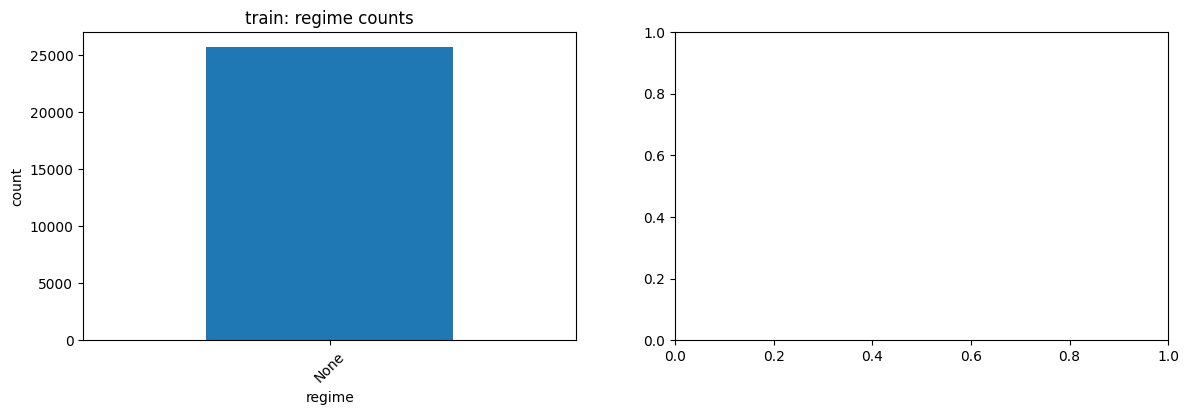

: 

In [ ]:
import pandas as pd
import torch

import matplotlib.pyplot as plt

loader_map = {
    "train": rand_train_loader,
    "val": rand_val_loader,
    "test": rand_test_loader,
}

sre_density_bins = [-1e-12, 1e-5, 0.05, 0.10, 0.20, 0.35, 0.50, 0.75, float("inf")]
sre_density_labels = [
    "zero",
    "tiny",
    "very_low",
    "low",
    "medium_low",
    "medium",
    "high",
    "very_high",
]

def _as_list(x):
    if torch.is_tensor(x):
        return x.detach().cpu().view(-1).tolist()
    if isinstance(x, tuple):
        return list(x)
    if isinstance(x, list):
        return x
    return [x]

def _extract_target_and_regime(batch):
    target = None
    for attr in ("y", "target", "sre_density", "sre"):
        if hasattr(batch, attr):
            target = getattr(batch, attr)
            break
    if target is None:
        raise AttributeError("Batch does not contain a target attribute.")

    targets = _as_list(target)

    regime = None
    for attr in ("regime", "family"):
        if hasattr(batch, attr):
            regime = getattr(batch, attr)
            break

    if regime is None:
        regimes = [None] * len(targets)
    else:
        regimes = _as_list(regime)
        if len(regimes) == 1 and len(targets) > 1:
            regimes = regimes * len(targets)

    return targets, regimes

def inspect_loader_distribution(loader, loader_name: str):
    rows = []
    for batch in loader:
        targets, regimes = _extract_target_and_regime(batch)
        for t, r in zip(targets, regimes):
            rows.append(
                {
                    "loader": loader_name,
                    "target": float(t),
                    "regime": r,
                },
            )

    df_loader = pd.DataFrame(rows)
    if df_loader.empty:
        print(f"\n[{loader_name}] no samples found.")
        return df_loader

    df_loader["sre_bin"] = pd.cut(
        df_loader["target"],
        bins=sre_density_bins,
        labels=sre_density_labels,
        include_lowest=True,
    )

    print(f"\n=== {loader_name.upper()} ===")
    print(f"Samples: {len(df_loader)}")

    print("\nTarget summary:")
    print(df_loader["target"].describe())

    print("\nRegime counts:")
    print(df_loader["regime"].value_counts(dropna=False))

    print("\nRegime x bin counts:")
    print(pd.crosstab(df_loader["regime"], df_loader["sre_bin"]))

    print("\nRegime x bin row-normalized distribution:")
    print(pd.crosstab(df_loader["regime"], df_loader["sre_bin"], normalize="index").round(4))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    df_loader["regime"].value_counts(dropna=False).sort_index().plot(
        kind="bar",
        ax=axes[0],
        title=f"{loader_name}: regime counts",
        rot=45,
    )
    axes[0].set_xlabel("regime")
    axes[0].set_ylabel("count")

    bin_dist = pd.crosstab(df_loader["regime"], df_loader["sre_bin"], normalize="index")
    bin_dist.plot(
        kind="bar",
        stacked=True,
        ax=axes[1],
        title=f"{loader_name}: sre bin distribution",
        colormap="viridis",
        rot=45,
    )
    axes[1].set_xlabel("regime")
    axes[1].set_ylabel("fraction")
    axes[1].legend(title="sre bin", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

    return df_loader

loader_dfs = {name: inspect_loader_distribution(loader, name) for name, loader in loader_map.items()}

In [72]:
import json
from pathlib import Path

import torch
import numpy as np
import pandas as pd


def _resolve_shard_path(index_path: Path, shard_path: str) -> str:
    raw_path = Path(shard_path)
    if raw_path.is_absolute():
        return str(raw_path.resolve())
    return str((index_path.parent / raw_path).resolve())


def load_sre_dataset(root: str | Path) -> pd.DataFrame:
    root = Path(root)
    rows = []

    index_paths = sorted({*root.rglob("index_*.jsonl"), *root.rglob("index.jsonl")})

    if index_paths:
        for index_path in index_paths:
            try:
                with index_path.open("r", encoding="utf-8") as handle:
                    for line in handle:
                        line = line.strip()
                        if not line:
                            continue

                        row = json.loads(line)
                        if not bool(row.get("has_target", False)):
                            continue

                        if "sre" not in row:
                            continue

                        sre = float(row["sre"])
                        if not np.isfinite(sre):
                            continue

                        n_qubits = int(row.get("n_qubits", -1))
                        row_out = dict(row)
                        row_out["index_path"] = str(index_path.resolve())
                        row_out["shard_path"] = _resolve_shard_path(index_path, row["shard_path"] )
                        row_out["path"] = row_out["shard_path"]
                        row_out["sre"] = sre
                        row_out["sre_density"] = float(row.get("sre_density", sre / n_qubits if n_qubits > 0 else np.nan))
                        row_out["n_qubits"] = n_qubits
                        row_out["n_layers"] = int(row.get("n_layers", -1))
                        row_out["seed"] = int(row.get("seed", -1))
                        rows.append(row_out)
            except Exception as exc:
                print(f"Could not load index {index_path}: {exc}")

        return pd.DataFrame(rows)

    for path in root.rglob("*.pt"):
        try:
            payload = torch.load(path, map_location="cpu", weights_only=False)
        except Exception as exc:
            print(f"Could not load {path}: {exc}")
            continue

        if not isinstance(payload, dict):
            continue

        meta = payload.get("meta", {})

        if "sre" not in payload:
            continue

        sre = float(payload["sre"])

        if not np.isfinite(sre):
            continue

        n_qubits = int(meta.get("n_qubits", -1))
        n_layers = int(meta.get("n_layers", -1))
        family = meta.get("family", "unknown")

        row = {
            "path": str(path),
            "family": family,
            "n_qubits": n_qubits,
            "n_layers": n_layers,
            "seed": int(meta.get("seed", -1)),
            "sre": sre,
            "sre_density": sre / n_qubits if n_qubits > 0 else np.nan,
            "regime": meta.get("regime", "unknown"),
        }

        controls = meta.get("sampling_controls", {})
        for k, v in controls.items():
            row[f"ctrl_{k}"] = v

        gate_counts = payload.get("gate_counts", {})
        for k, v in gate_counts.items():
            if isinstance(v, (int, float)):
                row[f"count_{k}"] = v

        rows.append(row)

    return pd.DataFrame(rows)

In [84]:
family = "clifford"
output_dir = f"../outputs/data/datasets_SRE/{family}"
df = load_sre_dataset(output_dir)

In [85]:
def add_sre_bins(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    bins = [-1e-12, 1e-5, 0.05, 0.10, 0.20, 0.35, 0.50, 0.75, np.inf]
    labels = [
        "zero",
        "tiny",
        "very_low",
        "low",
        "medium_low",
        "medium",
        "high",
        "very_high",
    ]

    df["sre_bin"] = pd.cut(
        df["sre_density"],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )

    return df

df_binned = add_sre_bins(df)

In [86]:
coverage_table = pd.crosstab(
    df_binned["family"],
    df_binned["sre_bin"],
    normalize="index",
)
print(coverage_table)

sre_bin       zero      tiny  very_low       low  medium_low    medium  \
family                                                                   
clifford  0.116303  0.016331  0.058291  0.131204    0.197031  0.155714   

sre_bin       high  very_high  
family                         
clifford  0.287395   0.037731  


In [87]:
# print(df_binned.head(10))
print(df.head(10))

                             cid    family  n_qubits  n_layers       seed  \
0    clifford_q004_L001_s2406892  clifford         4         1    2406892   
1   clifford_q004_L001_s19998767  clifford         4         1   19998767   
2   clifford_q004_L001_s42660196  clifford         4         1   42660196   
3   clifford_q004_L001_s51334631  clifford         4         1   51334631   
4   clifford_q004_L001_s69623402  clifford         4         1   69623402   
5  clifford_q004_L001_s150065912  clifford         4         1  150065912   
6  clifford_q004_L001_s170679152  clifford         4         1  170679152   
7  clifford_q004_L001_s188633086  clifford         4         1  188633086   
8  clifford_q004_L001_s200101944  clifford         4         1  200101944   
9  clifford_q004_L001_s202672842  clifford         4         1  202672842   

                       shard_id  \
0  clifford_q004_layers_001_018   
1  clifford_q004_layers_001_018   
2  clifford_q004_layers_001_018   
3  clifford_

In [80]:
print(df.describe())

           n_qubits      n_layers          seed     local_idx           sre  \
count  35700.000000  35700.000000  3.570000e+04  35700.000000  3.570000e+04   
mean       7.000000     50.019608  2.151717e+09    859.058824  3.400162e+00   
std        2.236099     29.406620  1.241561e+09    512.038130  2.365550e+00   
min        4.000000      1.000000  8.110900e+04      0.000000 -2.562741e-15   
25%        5.500000     24.000000  1.071990e+09    411.000000  1.638032e+00   
50%        7.000000     50.000000  2.161648e+09    857.000000  3.153243e+00   
75%        8.500000     76.000000  3.228558e+09   1303.000000  5.348991e+00   
max       10.000000    100.000000  4.294696e+09   1749.000000  8.013436e+00   

        sre_density  
count  3.570000e+04  
mean   4.727668e-01  
std    2.547005e-01  
min   -6.406853e-16  
25%    2.789501e-01  
50%    5.531874e-01  
75%    6.767214e-01  
max    8.013436e-01  


In [65]:
# _plot_SRE_distribution(rand_base_dataset, title="Random Circuits")
# _plot_SRE_distribution(cliff_base_dataset, title="Clifford Circuits")
# _plot_SRE_distribution(haar_base_dataset, title="Haar Circuits")
# _plot_SRE_distribution(quan_base_dataset, title="Quansistor Circuits")

ValueError: No valid finite SRE values found in the dataset.

# Training

In [45]:
def _amp_device_type() -> str:
    return "cuda" if torch.cuda.is_available() else "cpu"

In [46]:
huber_delta = 1.0
use_amp = True
device = _amp_device_type()
epochs=cfg.epochs
lr=cfg.lr
loss_type=cfg.loss_type
scheduler="plateau"
show_progress=cfg.show_progress
show_val_progress=cfg.show_val_progress
log_every_n_batches=cfg.log_batch_loss_every
heartbeat_secs=cfg.heartbeat
epoch_time_warning_secs=cfg.epoch_warning
weight_decay=train_hparams.get("weight_decay", 0.0)
grad_clip=train_hparams.get("grad_clip", None)
early_stopping_patience=train_hparams.get("early_stopping_patience", 30)
early_stopping_min_delta=train_hparams.get("early_stopping_min_delta", 0.0)

In [47]:
dev = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
if dev == "cuda":
    torch.backends.cudnn.benchmark = True
logger.info(f"Using device: {dev}")
model = model.to(dev)

loss_fn = build_loss(loss_type=loss_type, huber_delta=huber_delta)
optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

if scheduler == "plateau":
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5,
    )
elif scheduler == "none":
    lr_scheduler = None
else:
    msg = "scheduler must be 'none' or 'plateau'"
    raise ValueError(msg)

scaler = GradScaler(
    device=_amp_device_type(),
    enabled=(use_amp and dev.type == "cuda"),
)

history = TrainHistory(train_loss=[], val_loss=[], lr=[])

best_val_loss = float("inf")
best_state_dict = None
bad_epochs = 0

2026-06-25 10:35:01,688 - __main__ - INFO - Using device: cuda


In [48]:
history

TrainHistory(train_loss=[], val_loss=[], lr=[])

In [49]:
for epoch in range(1, epochs + 1):
        epoch_start_time = time.time()
        logger.info(f"-------- EPOCH {epoch:03d} --------")  # noqa: G004

        train_loss, train_time = _run_train_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            scaler=scaler,
            device=dev,
            use_amp=use_amp,
            grad_clip=grad_clip,
            epoch_idx=epoch,
            num_epochs=epochs,
            show_progress=show_progress,
            log_every_n_batches=log_every_n_batches,
            heartbeat_secs=heartbeat_secs,
        )

        logger.info(f"Training complete ({train_time:.1f}s) | running validation...")  # noqa: G004

        val_start_time = time.time()
        val_loss = evaluate_loss(
            model=model,
            loader=val_loader,
            device=dev,
            loss_fn=loss_fn,
            use_amp=use_amp,
            show_progress=show_val_progress,
        )
        val_time = time.time() - val_start_time

        if lr_scheduler is not None:
            lr_scheduler.step(val_loss)

        current_lr = float(optimizer.param_groups[0]["lr"])
        history.train_loss.append(float(train_loss))
        history.val_loss.append(float(val_loss))
        history.lr.append(current_lr)

        epoch_time = time.time() - epoch_start_time

        logger.info(
            f"Losses | train {train_loss:.6f} | val {val_loss:.6f} | "  # noqa: G004
            f"lr {current_lr:.2e} | time train={train_time:.1f}s "
            f"val={val_time:.1f}s total={epoch_time:.1f}s",
        )

        if epoch_time_warning_secs > 0 and epoch_time > epoch_time_warning_secs:
            logger.warning(
                f"Epoch {epoch} took {epoch_time:.1f}s "  # noqa: G004
                f"(>{epoch_time_warning_secs:.0f}s threshold).",
            )

        improved = val_loss + early_stopping_min_delta < best_val_loss
        if improved:
            best_val_loss = val_loss
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
            logger.debug(f"New best validation loss: {best_val_loss:.6f}")  # noqa: G004
        else:
            bad_epochs += 1
            logger.debug(
                f"No improvement: patience {bad_epochs}/{early_stopping_patience}",  # noqa: G004
            )
            if bad_epochs >= early_stopping_patience:
                logger.info(
                    f"Early stopping at epoch {epoch:03d} | "  # noqa: G004
                    f"best val {best_val_loss:.6f} | "
                    f"patience exhausted ({bad_epochs}/{early_stopping_patience})",
                )
                break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

2026-06-25 10:35:02,479 - __main__ - INFO - -------- EPOCH 001 --------


2026-06-25 10:35:16,388 - __main__ - INFO - Training complete (13.9s) | running validation...


2026-06-25 10:35:17,632 - __main__ - INFO - Losses | train 0.000516 | val 0.000010 | lr 9.86e-04 | time train=13.9s val=1.2s total=15.2s
2026-06-25 10:35:17,635 - __main__ - INFO - -------- EPOCH 002 --------


2026-06-25 10:35:32,455 - __main__ - INFO - Training complete (14.8s) | running validation...


2026-06-25 10:35:34,191 - __main__ - INFO - Losses | train 0.000053 | val 0.000008 | lr 9.86e-04 | time train=14.8s val=1.7s total=16.6s
2026-06-25 10:35:34,194 - __main__ - INFO - -------- EPOCH 003 --------


...

2026-06-25 10:38:39,103 - __main__ - INFO - Losses | train 0.000009 | val 0.000008 | lr 4.93e-04 | time train=15.0s val=1.4s total=16.4s
2026-06-25 10:38:39,103 - __main__ - INFO - -------- EPOCH 014 --------


2026-06-25 10:38:54,210 - __main__ - INFO - Training complete (15.1s) | running validation...


2026-06-25 10:38:55,640 - __main__ - INFO - Losses | train 0.000009 | val 0.000009 | lr 2.47e-04 | time train=15.1s val=1.4s total=16.5s
2026-06-25 10:38:55,641 - __main__ - INFO - -------- EPOCH 015 --------


2026-06-25 10:39:11,085 - __main__ - INFO - Training complete (15.4s) | running validation...


2026-06-25 10:39:12,718 - __main__ - INFO - Losses | train 0.000009 | val 0.000008 | lr 2.47e-04 | time train=15.4s val=1.6s total=17.1s


In [50]:
loss_fn = build_loss(cfg.loss_type, huber_delta=1.0)

test_loss = evaluate_loss(
    model,
    test_loader,
    dev,
    loss_fn,
    use_amp=True,
    show_progress=show_progress,
)
print(f"Test loss: {test_loss:.6f}")

Test loss: 0.000007


In [51]:
train_r2_score = evaluate_r2(
    model,
    train_loader,
    dev,
    show_progress=show_progress,
)

print(f"Train R^2 score: {train_r2_score:.6f}")

Train R^2 score: 0.002933


In [52]:
val_r2_score = evaluate_r2(
    model,
    val_loader,
    dev,
    show_progress=show_progress,
)
print(f"Validation R^2 score: {val_r2_score:.6f}")

Validation R^2 score: 0.014816


In [53]:
test_r2_score = evaluate_r2(
    model,
    test_loader,
    dev,
    show_progress=show_progress,
)
print(f"Test R^2 score: {test_r2_score:.6f}")

Test R^2 score: 0.010549


In [54]:
logger.info("Training complete.")

run_name = f"{model_type}_{loss_type}_{family if training_mode == 'per_family' else 'global'}"

plot_training_curves(
    history,
    title=f"{model_type.upper()} SRE regression",
    save_fig=True,
    fig_path=f"final/figures/training_curves_{run_name}.png",
)

2026-06-25 10:39:36,824 - __main__ - INFO - Training complete.
2026-06-25 10:39:36,879 - experiments.plotting - INFO - Saved training curve plot to final\figures\training_curves_gnn_huber_random_4.png


In [55]:
save_checkpoint = True
allow_overwrite = True

model_config = {
    "node_in_dim": node_in_dim or None,
    "global_in_dim": global_in_dim,
    "hidden_dim": model_hparams.get("hidden_dim", 64),
    "dropout_rate": model_hparams.get("dropout_rate", 0.1),
}
# GNN specific params (only meaningful for gnn models)
model_config.update({
    "gnn_hidden": model_hparams.get("gnn_hidden", None),
    "gnn_heads": model_hparams.get("gnn_heads", None),
    "global_hidden": model_hparams.get("global_hidden", None),
    "reg_hidden": model_hparams.get("reg_hidden", None),
    "num_layers": model_hparams.get("num_layers", None),
})

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_type": model_type,
    "model_config": model_config,
    "target_variant": target_variant,
    "train_config": asdict(cfg),
    "train_hparams": train_hparams,
    "feature_config": {
        "global_feature_variant": cfg.global_feature_variant,
        "node_feature_backend_variant": cfg.node_feature_backend_variant,
        "all_gate_keys": getattr(base_dataset, "all_gate_keys", None),
        "family_projection": family_projection,
    },
    "final_metrics": {
        "test_loss": float(test_loss),
        "test_r2_score": float(test_r2_score),
        "train_r2_score": float(train_r2_score),
        "val_r2_score": float(val_r2_score),
    },
    "history": history,
}
model_path_root = Path("final/models")
model_path_root.mkdir(parents=True, exist_ok=True)
if save_checkpoint and model_save_path is None:
    model_save_path = _resolve_model_save_path(
        f"{model_path_root}/{run_name}.pt",
        allow_overwrite=allow_overwrite,
    )
    model_save_path = Path(str(model_save_path))
    if model_save_path.suffix == "":
        model_save_path.mkdir(parents=True, exist_ok=True)
        checkpoint_file = model_save_path / f"{family}_model_{model_type}_{training_scope}.pt"
    else:
        model_save_path.parent.mkdir(parents=True, exist_ok=True)
        checkpoint_file = model_save_path
    torch.save(checkpoint, checkpoint_file)
    logger.info(f"Saved model checkpoint to {checkpoint_file}")
elif save_checkpoint and model_save_path is not None:
    path: str = _resolve_model_save_path(
            model_save_path,
            allow_overwrite=allow_overwrite,
        )
    model_save_path = Path(path)

    model_save_path.parent.mkdir(parents=True, exist_ok=True)

    torch.save(checkpoint, model_save_path)
    logger.info(f"Saved model checkpoint to {model_save_path}")

2026-06-25 10:39:37,249 - __main__ - INFO - Saved model checkpoint to ..\notebooks\outputs\models\final\random_model_gnn_per_family_sre_density.pt


In [56]:
training_scope = "family" if training_mode == "per_family" else "global"
model_save_path = f"../notebooks/outputs/models/final/{family}_model_{model_type}_{training_mode}_{target_variant}.pt"

batch_size = 16
predictions(
    model_path=model_save_path,
    model_kind=model_type,
    training_scope=training_scope,
    target_variant=target_variant,
    loss_type=loss_type,
    model_family=family,
    dataset_root=training_data_dir,
    dataset_family=family,
    batch_size=batch_size,
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    plot_n_layers=plot_layers,
    plot_n_qubits=plot_qubits,
    split_by_family=True,
    show_progress=True,
)

2026-06-25 10:39:37,606 - scripts.predictions - INFO - Loading checkpoint: ../notebooks/outputs/models/final/random_model_gnn_per_family_sre_density.pt
2026-06-25 10:39:37,611 - scripts.predictions - INFO - Using target_variant from checkpoint: sre_density
2026-06-25 10:39:37,621 - scripts.predictions - INFO - Found 1 prediction files


Detected node feature dims: [17, 19, 21, 23]
Detected global feature dims: [13770, 22950]
=== Prediction dataset sample ===
target_variant: sre_density
x: torch.Size([12, 23])
global_features: torch.Size([1, 22950])
y: tensor([-0.])
sre: tensor([-0.])
raw_sre: tensor([-0.])
n_qubits: tensor([4])
node_in_dim checkpoint: 16
global_in_dim checkpoint: 2
family_projection: random
all_gate_keys len: 0


Predicting (gnn): 100%|██████████| 285/285 [00:28<00:00,  9.91batch/s]
2026-06-25 10:40:08,427 - scripts.predictions - INFO - Saved 4560 predictions to outputs/predictions/family/gnn_predictions_random.csv


In [57]:
plot_qubits = 8
plot_layers = 40
family = "random"
df = pd.read_csv(f"outputs/predictions/family/gnn_predictions_{family}.csv")
# df = pd.read_csv(f"../notebooks/final/predictions/gnn_predictions_{family}.csv")
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)

new_df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]

print(new_df["target_sre"].describe())
print(new_df["predicted_sre"].describe())

count    1.500000e+01
mean     1.301856e-03
std      1.171072e-03
min      1.014399e-08
25%      2.173891e-04
50%      1.209603e-03
75%      1.689042e-03
max      4.228979e-03
Name: target_sre, dtype: float64
count    15.000000
mean      0.024485
std       0.000024
min       0.024452
25%       0.024467
50%       0.024481
75%       0.024510
max       0.024517
Name: predicted_sre, dtype: float64


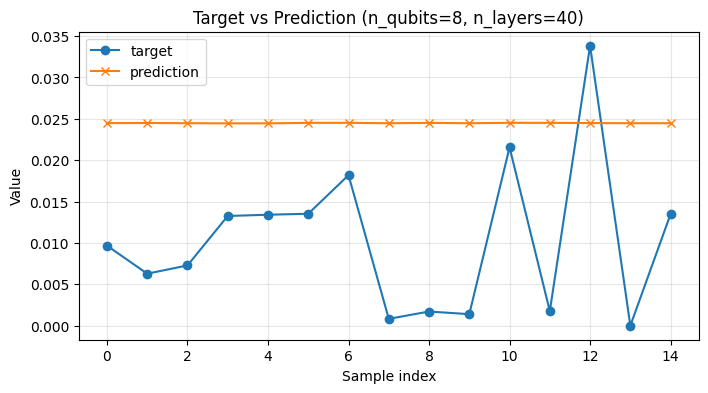

Pearson r = 0.1803


Text(0.5, 1.0, 'True vs Predicted SRE for Quansistor Family (GNN Model)')

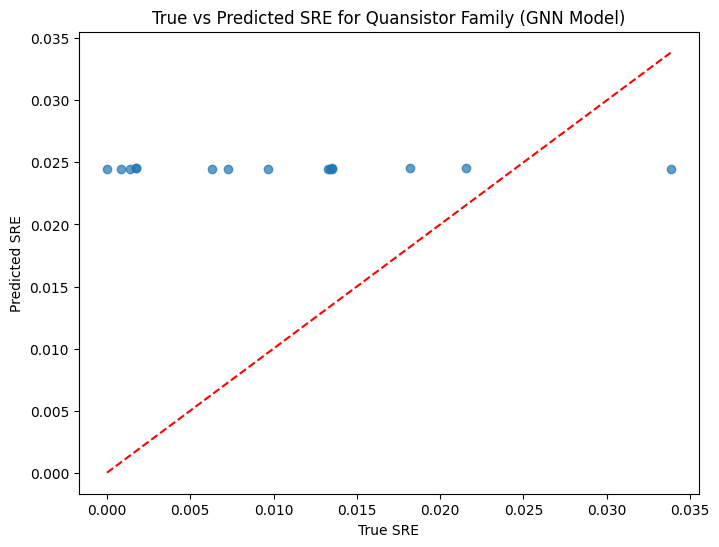

In [58]:
nq=plot_qubits
nl=plot_layers

df["target_sre"] = df["target_sre"] * nq

view_correlation(
    df,
    nq=plot_qubits,
    nl=plot_layers,
    col_x="target_sre",
    col_y="predicted_sre",
)
df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
plt.figure(figsize=(8, 6))
plt.scatter(df["target_sre"], df["predicted_sre"], alpha=0.7)
plt.plot([df["target_sre"].min(), df["target_sre"].max()], [df["target_sre"].min(), df["target_sre"].max()], "r--")  # y=x line
plt.xlabel("True SRE")
plt.ylabel("Predicted SRE")
plt.title("True vs Predicted SRE for Quansistor Family (GNN Model)")

## Generating new datasets

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from experiments.plotting import _plot_SRE_distribution
from GNN.dataset_builder import (
    DataGenConfig,
    RegimeDistribution,
    SamplingConfig,
    run_dataset_pipeline,
)